**CIFAR-10 Image Classification** --> The CIFAR-10 dataset consists of 60000 32x32 color images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

**Problem Definition**

Given an image, can we predict the correct class of this image?

The images are very small (32x32) and by visualizing them you will notice how difficult it is to distinguish them even for a human.

In this notebook we are going to build a CNN model that can classify images of various objects. We have 10 class of images:

1. Plane
2. Car
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.2 MB/s eta 0:00:00


Step -1: Importing all dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
import optuna
from PIL import Image
import seaborn as sns

**Step -2: Load the dataset**

In [3]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train Shape: (50000, 32, 32, 3)
X_test Shape: (10000, 32, 32, 3)
y_train Shape: (50000, 1)
y_test Shape: (10000, 1)


In [5]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [6]:
y_train = y_train.reshape(-1)

In [7]:
y_train

array([6, 9, 9, ..., 9, 1, 1], dtype=uint8)

In [8]:
np.unique(y_train,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]))

In [9]:
class_names = ['plane','car','bird','deer','cat','dog','frog','horse','ship','truck']

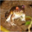

In [10]:
Image.fromarray(X_train[0])

In [11]:
print(class_names[y_train[0]])

frog


In [12]:
X_train[0].shape

(32, 32, 3)

Text(0.5, 1.0, 'Class distribution in training set')

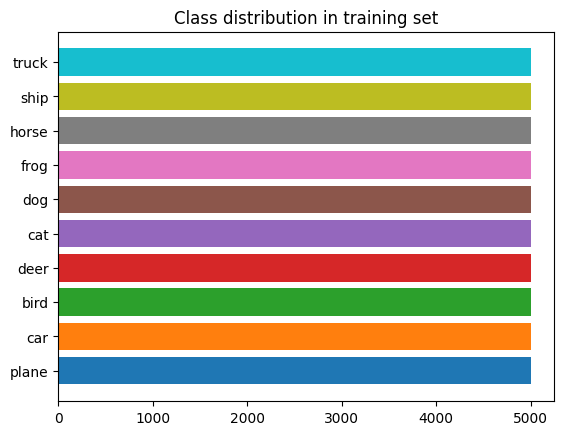

In [13]:
classes, counts = np.unique(y_train, return_counts=True)
class_names[classes[0]]
for i in range(len(classes)):
    plt.barh(class_names[i], counts)
plt.title('Class distribution in training set')

Text(0.5, 1.0, 'Class distribution in test set')

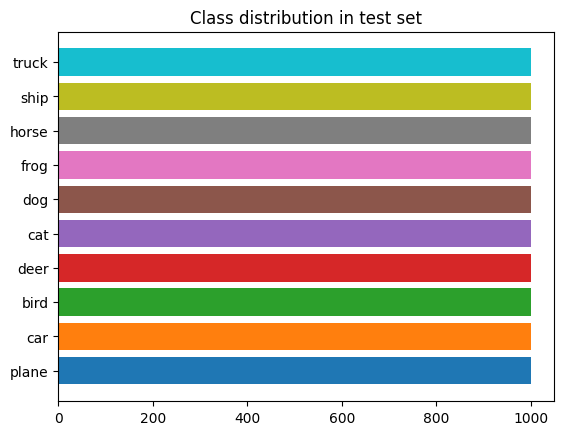

In [14]:
y_test = y_test.reshape(-1)

classes, counts = np.unique(y_test, return_counts=True)
for i in range(len(classes)):
    plt.barh(class_names[i], counts)
plt.title('Class distribution in test set')

In [15]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
y_cat_train = encoder.fit_transform(np.expand_dims(y_train,axis=1))
y_cat_test = encoder.transform(np.expand_dims(y_test,axis=1))
y_cat_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [16]:
print(y_cat_train.shape)
print(y_cat_test.shape)

(50000, 10)
(10000, 10)


In [17]:
# Scaling the test and train

X_train = X_train/255.0
X_test = X_test/255.0

In [18]:
INPUT_SHAPE = (32, 32, 3)
KERNEL_SIZE = (3, 3)
model = Sequential()

# Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=KERNEL_SIZE, input_shape=INPUT_SHAPE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=32,kernel_size=KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
# Pooling layer
model.add(MaxPool2D(pool_size=(2, 2)))
# Dropout layers
model.add(Dropout(0.25))

model.add(Conv2D(filters=64, kernel_size=KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64,kernel_size=KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters=128, kernel_size=KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=KERNEL_SIZE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
# model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

METRICS = [
    'accuracy'
]
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=METRICS)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,29

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [20]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)
lr_scheduler = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

batch_size = 32

history = model.fit(X_train,y_cat_train,
              epochs=50,
              validation_data=(X_test, y_cat_test),
              callbacks=[early_stop, lr_scheduler],
              batch_size=batch_size,
             )

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.4538 - loss: 1.5112 - val_accuracy: 0.5999 - val_loss: 1.1517 - learning_rate: 0.0010
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6294 - loss: 1.0607 - val_accuracy: 0.6943 - val_loss: 0.8841 - learning_rate: 0.0010
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6963 - loss: 0.8882 - val_accuracy: 0.7116 - val_loss: 0.8387 - learning_rate: 0.0010
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7311 - loss: 0.7819 - val_accuracy: 0.7371 - val_loss: 0.7655 - learning_rate: 0.0010
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7583 - loss: 0.7037 - val_accuracy: 0.7732 - val_loss: 0.6704 - learning_rate: 0.0010
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7801 - loss: 0.6457 - val_accuracy: 0.7653 - val_loss: 0.6891 - learning_rate: 0.0010
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7

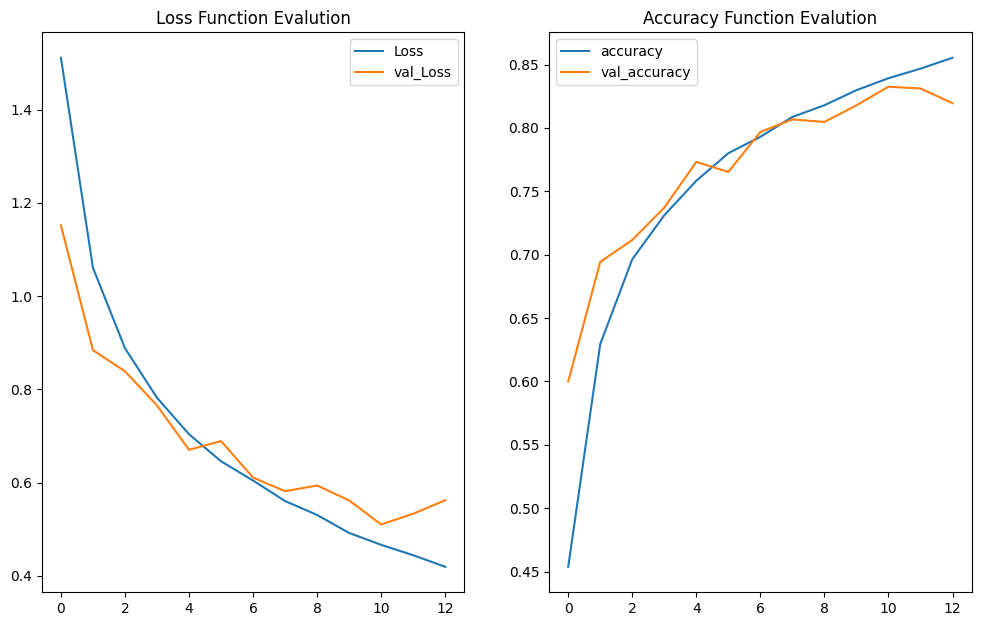

In [36]:
plt.figure(figsize=(12, 16))

plt.subplot(2,2,1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='val_Loss')
plt.title('Loss Function Evalution')
plt.legend()

plt.subplot(2,2,2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Function Evalution')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


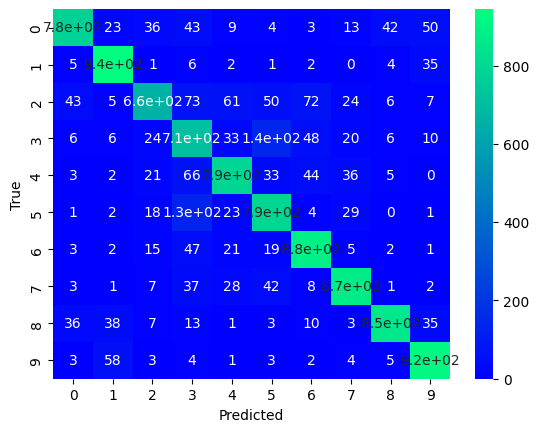

In [23]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='winter')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1000
           1       0.87      0.94      0.91      1000
           2       0.83      0.66      0.74      1000
           3       0.63      0.71      0.66      1000
           4       0.82      0.79      0.80      1000
           5       0.73      0.79      0.76      1000
           6       0.82      0.89      0.85      1000
           7       0.87      0.87      0.87      1000
           8       0.92      0.85      0.89      1000
           9       0.87      0.92      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



**Using pre-trained Model DenseNet121**

In [25]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64,64,3))

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/tmp/ipykernel_16600/1389563434.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64,64,3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
X_train.shape

(50000, 32, 32, 3)

In [27]:
X_test.shape

(10000, 32, 32, 3)

In [28]:
batch_size = 8
early_stop = EarlyStopping(monitor='val_loss', patience=2)

X_train = tf.image.resize(X_train, (64, 64))
X_test = tf.image.resize(X_test, (64, 64))

r = model.fit(X_train, y_cat_train,
              epochs=100,
              validation_data=(X_test, y_cat_test),
              callbacks=[early_stop],
              batch_size=batch_size,
             )

Epoch 1/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - accuracy: 0.3097 - loss: 2.0563 - val_accuracy: 0.5538 - val_loss: 1.2937
Epoch 2/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 49s 8ms/step - accuracy: 0.4900 - loss: 1.4804 - val_accuracy: 0.6398 - val_loss: 1.0623
Epoch 3/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - accuracy: 0.5587 - loss: 1.3004 - val_accuracy: 0.6771 - val_loss: 0.9624
Epoch 4/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 49s 8ms/step - accuracy: 0.6034 - loss: 1.1828 - val_accuracy: 0.7097 - val_loss: 0.8700
Epoch 5/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 87s 9ms/step - accuracy: 0.6277 - loss: 1.1059 - val_accuracy: 0.7220 - val_loss: 0.8306
Epoch 6/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 49s 8ms/step - accuracy: 0.6487 - loss: 1.0436 - val_accuracy: 0.7314 - val_loss: 0.8042
Epoch 7/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 49s 8ms/step - accuracy: 0.6679 - loss: 0.9955 - val_accuracy: 0.7434 - val_loss: 0.7713
Epoch 8/100
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 51s 8ms/step - accuracy: 0.6831 -

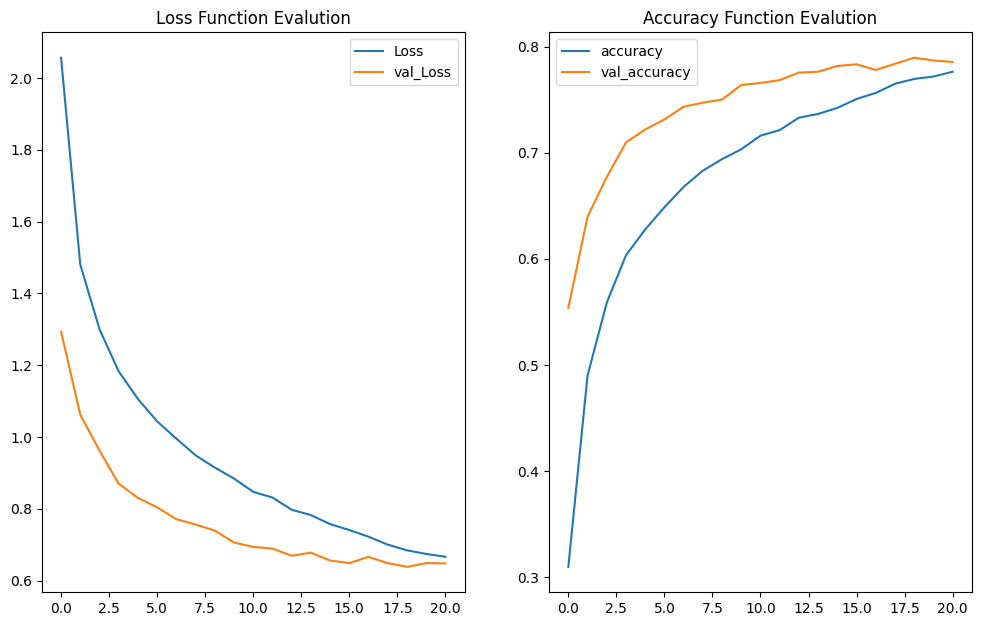

In [35]:
plt.figure(figsize=(12, 16))

plt.subplot(2,2,1)
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='val_Loss')
plt.title('Loss Function Evalution')
plt.legend()

plt.subplot(2,2,2)
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Function Evalution')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


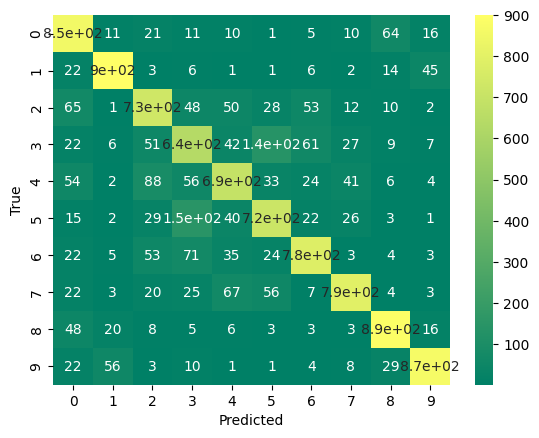

In [32]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='summer')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.85      0.79      1000
           1       0.89      0.90      0.90      1000
           2       0.73      0.73      0.73      1000
           3       0.63      0.64      0.63      1000
           4       0.73      0.69      0.71      1000
           5       0.72      0.72      0.72      1000
           6       0.81      0.78      0.79      1000
           7       0.86      0.79      0.82      1000
           8       0.86      0.89      0.87      1000
           9       0.90      0.87      0.88      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



**Result -> Firstly took pre-trained model and then trained it keeping base model as untrainable. The accuracy obtained was not great. Then, tried to built Custom CNN architecture with multiple Layers, Dropouts, Learning Rate schedulers and then accuracy obtained is 85%.

In [92]:
img = Image.open('/content/two.jpg')

In [93]:
img = img.resize((32,32))

In [94]:
img_array = np.array(img)

array([[[ 89, 137, 202],
        [ 89, 137, 202],
        [ 89, 137, 202],
        ...,
        [183, 210, 237],
        [180, 208, 236],
        [175, 204, 234]],

       [[ 92, 139, 201],
        [ 92, 139, 201],
        [ 92, 139, 201],
        ...,
        [177, 206, 234],
        [173, 202, 232],
        [167, 198, 230]],

       [[ 94, 140, 201],
        [ 94, 140, 200],
        [ 94, 140, 200],
        ...,
        [169, 200, 231],
        [164, 196, 229],
        [158, 190, 227]],

       ...,

       [[  8,  43,  65],
        [  9,  45,  68],
        [ 10,  48,  71],
        ...,
        [ 25,  73, 102],
        [ 21,  65,  94],
        [ 19,  62,  90]],

       [[  5,  34,  52],
        [  7,  38,  57],
        [  7,  40,  60],
        ...,
        [ 16,  68,  96],
        [ 14,  63,  90],
        [ 12,  57,  82]],

       [[  4,  29,  45],
        [  5,  31,  49],
        [  4,  36,  55],
        ...,
        [  9,  66,  89],
        [  7,  59,  82],
        [  6,  51,  72]]], dtype=uint8)
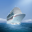

In [95]:
img_array

In [96]:
img_array = img_array/255

In [97]:
img_array = np.expand_dims(img_array, axis=0)

In [98]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [99]:
pred

array([[0.54582673, 0.00303609, 0.09562907, 0.16924699, 0.02621423,
        0.03379289, 0.03254942, 0.00260467, 0.08824531, 0.00285462]],
      dtype=float32)

In [100]:
print(class_names[np.argmax(pred)])

plane
